Importing the Libraries

In [1]:

import os
import random
import shutil
import json
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input, Dense, Dropout, concatenate,
    GlobalAveragePooling1D, Layer, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Checking the size of the image in each files

In [2]:
import os
import cv2


datasets = {
    "CT": "CT_Scans",
    "XRAY": "X_Ray"
}


for dataset_name, dataset_path in datasets.items():

    

    # Loop through each class folder
    for class_name in os.listdir(dataset_path):

        class_path = os.path.join(dataset_path, class_name)

        # Check if folder exists
        if os.path.isdir(class_path):

            print(f"\nClass: {class_name}")

            count = 0

            # Loop through images
            for img_name in os.listdir(class_path):

                img_path = os.path.join(class_path, img_name)

                # Read image
                img = cv2.imread(img_path)

                if img is not None:

                    print(f"{img_name} --> {img.shape}")

                    count += 1

                # Show only first 5 images
                if count == 5:
                    break


Class: COVID
COVID-19_0001.png --> (512, 512, 3)
COVID-19_0002.png --> (512, 512, 3)
COVID-19_0003.png --> (512, 512, 3)
COVID-19_0004.png --> (512, 512, 3)
COVID-19_0005.png --> (512, 512, 3)

Class: NORMAL
16_Morozov_study_0001_12.png --> (512, 512, 3)
16_Morozov_study_0001_13.png --> (512, 512, 3)
16_Morozov_study_0001_14.png --> (512, 512, 3)
16_Morozov_study_0001_15.png --> (512, 512, 3)
16_Morozov_study_0001_16.png --> (512, 512, 3)

Class: PNEUMONIA
cap006_10.png --> (512, 512, 3)
cap006_11.png --> (512, 512, 3)
cap006_12.png --> (512, 512, 3)
cap006_14.png --> (512, 512, 3)
cap006_15.png --> (512, 512, 3)

Class: COVID
COVID.png --> (256, 256, 3)
COVID_10.png --> (256, 256, 3)
COVID_100.png --> (256, 256, 3)
COVID_1000.png --> (232, 232, 3)
COVID_1001.png --> (232, 232, 3)

Class: NORMAL
NORMAL.png --> (232, 232, 3)
NORMAL_10.png --> (232, 232, 3)
NORMAL_100.png --> (232, 232, 3)
NORMAL_1000.png --> (232, 232, 3)
NORMAL_1001.png --> (232, 232, 3)

Class: PNEUMONIA
PNEUMONIA.pn

counting the image in the dataset

In [3]:
import os

datasets = {
    "CT": "CT_Scans",
    "XRAY": "X_Ray"
}

for dataset_name, dataset_path in datasets.items():

    print(f"\n===== {dataset_name} Dataset =====")

    for class_name in os.listdir(dataset_path):

        class_path = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_path):

            total_images = len(os.listdir(class_path))

            print(f"{class_name}: {total_images} images")


===== CT Dataset =====
COVID: 7496 images
NORMAL: 3562 images
PNEUMONIA: 2618 images

===== XRAY Dataset =====
COVID: 1626 images
NORMAL: 1802 images
PNEUMONIA: 1800 images


Balancing the CTScan Dataset

In [4]:

random.seed(42)
data="CT_Scans"
DESTINATION_PATH = "Balanced_CT"


TARGET_COUNT = {
    "COVID": 2600,
    "NORMAL": 2600,
    "PNEUMONIA": 2600
}


os.makedirs(DESTINATION_PATH, exist_ok=True)

for class_name in TARGET_COUNT:

    source_class_path = os.path.join(data, class_name)

    destination_class_path = os.path.join(DESTINATION_PATH, class_name)

    # Create class folder
    os.makedirs(destination_class_path, exist_ok=True)

    # Get all images
    all_images = os.listdir(source_class_path)

    # Shuffle images randomly
    random.shuffle(all_images)

    # Select target number of images
    selected_images = all_images[:TARGET_COUNT[class_name]]

    print(f"\nProcessing {class_name}")
    print(f"Selected Images: {len(selected_images)}")

    # Copy selected images
    for img_name in selected_images:

        source_img_path = os.path.join(source_class_path, img_name)

        destination_img_path = os.path.join(destination_class_path, img_name)

        shutil.copy2(source_img_path, destination_img_path)

print("\nCT Dataset Balanced Successfully!")


Processing COVID
Selected Images: 2600

Processing NORMAL
Selected Images: 2600

Processing PNEUMONIA
Selected Images: 2600

CT Dataset Balanced Successfully!


Dataset Path

In [5]:
CT_PATH = "Balanced_CT"
XRAY_PATH = "X_Ray"

In [6]:
classes = {
    "COVID": 0,
    "NORMAL": 1,
    "PNEUMONIA": 2
}


Image Preprocessing

In [7]:

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 3
NUM_PATCHES = 9
SEED = 42
VAL_SPLIT = 0.15

CT_PATH = "Balanced_CT"
XRAY_PATH = "X_Ray"
CLASS_NAMES = ['COVID', 'NORMAL', 'PNEUMONIA']
IMG_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

import hashlib
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split


def file_md5(path):
    hasher = hashlib.md5()
    with open(path, 'rb') as file_obj:
        for chunk in iter(lambda: file_obj.read(1024 * 1024), b''):
            hasher.update(chunk)
    return hasher.hexdigest()


def collect_image_dataframe(dataset_path, class_names):
    rows = []
    for class_id, class_name in enumerate(class_names):
        class_dir = Path(dataset_path) / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")

        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                rows.append({
                    'path': str(image_path),
                    'label': class_id,
                    'class_name': class_name,
                    'hash': file_md5(image_path)
                })

    return pd.DataFrame(rows)


def remove_duplicate_images(df, modality_name):
    before = len(df)
    duplicate_rows = df[df.duplicated(['class_name', 'hash'], keep=False)].sort_values(['class_name', 'hash', 'path'])
    deduped = df.drop_duplicates(['class_name', 'hash'], keep='first').reset_index(drop=True)
    removed = before - len(deduped)
    print(f"{modality_name}: {before} files, removed {removed} exact duplicate images, kept {len(deduped)}")
    if removed:
        print(duplicate_rows.groupby('class_name').size().rename('duplicate_rows'))
    return deduped


def split_no_leak(df, modality_name):
    train_df, val_df = train_test_split(
        df,
        test_size=VAL_SPLIT,
        stratify=df['label'],
        random_state=SEED,
        shuffle=True
    )

    train_hashes = set(train_df['hash'])
    val_hashes = set(val_df['hash'])
    leaked_hashes = train_hashes & val_hashes
    if leaked_hashes:
        raise ValueError(f"{modality_name} leakage: {len(leaked_hashes)} duplicate image hashes appear in both train and validation")

    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    val_df = val_df.sort_values(['label', 'path']).reset_index(drop=True)

    print(f"\n{modality_name} split")
    print("Train:")
    print(train_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))
    print("Validation:")
    print(val_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))
    return train_df, val_df


ct_all_df = remove_duplicate_images(collect_image_dataframe(CT_PATH, CLASS_NAMES), 'CT')
xray_all_df = remove_duplicate_images(collect_image_dataframe(XRAY_PATH, CLASS_NAMES), 'X-ray')

ct_train_df, ct_val_df = split_no_leak(ct_all_df, 'CT')
xray_train_df, xray_val_df = split_no_leak(xray_all_df, 'X-ray')

print("\nClass mapping:", {name: idx for idx, name in enumerate(CLASS_NAMES)})


CT: 7800 files, removed 127 exact duplicate images, kept 7673
class_name
NORMAL    254
Name: duplicate_rows, dtype: int64
X-ray: 5228 files, removed 229 exact duplicate images, kept 4999
class_name
COVID        161
NORMAL       234
PNEUMONIA     18
Name: duplicate_rows, dtype: int64

CT split
Train:
class_name
COVID        2210
NORMAL       2102
PNEUMONIA    2210
Name: count, dtype: int64
Validation:
class_name
COVID        390
NORMAL       371
PNEUMONIA    390
Name: count, dtype: int64

X-ray split
Train:
class_name
COVID        1307
NORMAL       1420
PNEUMONIA    1522
Name: count, dtype: int64
Validation:
class_name
COVID        230
NORMAL       251
PNEUMONIA    269
Name: count, dtype: int64

Class mapping: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


In [9]:

print("\n===== CT DATASET =====")
print("Train images:", len(ct_train_df))
print("Validation images:", len(ct_val_df))
print(ct_train_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))
print(ct_val_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))

print("\n===== XRAY DATASET =====")
print("Train images:", len(xray_train_df))
print("Validation images:", len(xray_val_df))
print(xray_train_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))
print(xray_val_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))



===== CT DATASET =====
Train images: 6522
Validation images: 1151
class_name
COVID        2210
NORMAL       2102
PNEUMONIA    2210
Name: count, dtype: int64
class_name
COVID        390
NORMAL       371
PNEUMONIA    390
Name: count, dtype: int64

===== XRAY DATASET =====
Train images: 4249
Validation images: 750
class_name
COVID        1307
NORMAL       1420
PNEUMONIA    1522
Name: count, dtype: int64
class_name
COVID        230
NORMAL       251
PNEUMONIA    269
Name: count, dtype: int64


CT Scan images Model -MobileNet

XRay Images Model -MobileNet

Prototype Intialization 

In [10]:
class PatchExtractor(Layer):
    def __init__(self, num_patches=9, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.grid = int(num_patches ** 0.5)

    def call(self, feature_map):
        h = tf.shape(feature_map)[1]
        w = tf.shape(feature_map)[2]
        patch_h = h // self.grid
        patch_w = w // self.grid

        patches = []
        for i in range(self.grid):
            for j in range(self.grid):
                patch = feature_map[
                    :,
                    i * patch_h:(i + 1) * patch_h,
                    j * patch_w:(j + 1) * patch_w,
                    :
                ]
                patches.append(tf.reduce_mean(patch, axis=[1, 2]))

        return tf.stack(patches, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

Patch Extraction   = For XRay and CTScan 

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling1D, concatenate, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

IMG_SIZE = 224
NUM_CLASSES = 3
NUM_PATCHES = 9
REG_L2 = 1e-5

ct_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="ct_input")
xray_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="xray_input")

ct_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    name="mobilenet_ct"
)

xray_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    name="mobilenet_xray"
)

ct_base.trainable = False
xray_base.trainable = False

ct_features = ct_base(ct_input, training=False)
xray_features = xray_base(xray_input, training=False)

ct_patches = PatchExtractor(num_patches=NUM_PATCHES, name="ct_patches")(ct_features)
xray_patches = PatchExtractor(num_patches=NUM_PATCHES, name="xray_patches")(xray_features)


Markov Decision Process

In [12]:
# MDP-inspired modality selection before fusion
ct_state_score = Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(REG_L2),
    name="ct_mdp_state_score"
)(ct_patches)
xray_state_score = Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(REG_L2),
    name="xray_mdp_state_score"
)(xray_patches)

ct_weighted = Multiply(name="ct_mdp_weighted")([ct_patches, ct_state_score])
xray_weighted = Multiply(name="xray_mdp_weighted")([xray_patches, xray_state_score])


Combine Both + Patch Selection
CT and XRay patches are concatenated â†’ 18 patches total. A small attention layer scores each patch (0â€“1). High score = more important. This is the Patch Selection step from your pipeline.

In [13]:
combined = concatenate([ct_weighted, xray_weighted], axis=1, name="combine_patches")

attn_scores = Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(REG_L2),
    name="patch_attention"
)(combined)
selected = Multiply(name="patch_selection")([combined, attn_scores])
aggregated = GlobalAveragePooling1D(name="aggregate")(selected)

print("Aggregated shape:", aggregated.shape)


Aggregated shape: (None, 1280)


ProtoRadNet Model Creation

In [14]:
x = Dense(
    192,
    activation="relu",
    kernel_regularizer=regularizers.l2(REG_L2),
    name="fc1"
)(aggregated)
x = Dropout(0.45, name="drop1")(x)
x = Dense(
    96,
    activation="relu",
    kernel_regularizer=regularizers.l2(REG_L2),
    name="fc2"
)(x)
x = Dropout(0.35, name="drop2")(x)
output = Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=regularizers.l2(REG_L2),
    name="predictions"
)(x)

model = Model(inputs=[ct_input, xray_input], outputs=output, name="ProtoRadNet_Fusion")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "ProtoRadNet_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ct_input            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_ct        │ (None, 7, 7,      │  2,257,984 │ ct_input[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_xray      │ (None, 7, 7,      │  2,257,984 │ xray_input[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_patches          │ (None, 9, 1280)   │          0 │ mobilenet_ct[0][… │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_patches        │ (None, 9, 1280)   │          0 │ mobilenet_xray[0… │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_mdp_state_score  │ (None, 9, 1)      │      1,281 │ ct_patches[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_mdp_state_sco… │ (None, 9, 1)      │      1,281 │ xray_patches[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_mdp_weighted     │ (None, 9, 1280)   │          0 │ ct_patches[0][0], │
│ (Multiply)          │                   │            │ ct_mdp_state_sco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_mdp_weighted   │ (None, 9, 1280)   │          0 │ xray_patches[0][… │
│ (Multiply)          │                   │            │ xray_mdp_state_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combine_patches     │ (None, 18, 1280)  │          0 │ ct_mdp_weighted[… │
│ (Concatenate)       │                   │            │ xray_mdp_weighte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_attention     │ (None, 18, 1)     │      1,281 │ combine_patches[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_selection     │ (None, 18, 1280)  │          0 │ combine_patches[… │
│ (Multiply)          │                   │            │ patch_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aggregate           │ (None, 1280)      │          0 │ patch_selection[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 192)       │    245,952 │ aggregate[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 192)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 96)        │     18,528 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 96)        │          0 │ fc2[0][0]       

 Total params: 4,784,582 (18.25 MB)

 Trainable params: 268,614 (1.02 MB)

 Non-trainable params: 4,515,968 (17.23 MB)

In [15]:
CLASS_NAMES = ['COVID', 'NORMAL', 'PNEUMONIA']

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)


K-fold Cross Validation

In [ ]:

from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
import tensorflow as tf

N_SPLITS = 3
K_FOLD_EPOCHS = 5
K_FOLD_BATCH_SIZE = 4  # Lower memory use for two-input MobileNetV2 k-fold training.

#CT and X-ray images belonging to the same class are paired together.
def make_paired_dataframe(ct_df, xray_df, seed=SEED):
    paired_rows = []
    rng = np.random.default_rng(seed)

    for class_id, class_name in enumerate(CLASS_NAMES):
        ct_class = ct_df[ct_df['label'] == class_id].sample(frac=1, random_state=seed).reset_index(drop=True)
        xray_class = xray_df[xray_df['label'] == class_id].sample(frac=1, random_state=seed + class_id + 1).reset_index(drop=True)
        pair_count = min(len(ct_class), len(xray_class))
        order = rng.permutation(pair_count)

        for i in order:
            paired_rows.append({
                'ct_path': ct_class.loc[i, 'path'],
                'xray_path': xray_class.loc[i, 'path'],
                'ct_hash': ct_class.loc[i, 'hash'],
                'xray_hash': xray_class.loc[i, 'hash'],
                'label': class_id,
                'class_name': class_name
            })

    return pd.DataFrame(paired_rows).sample(frac=1, random_state=seed).reset_index(drop=True)


paired_df = make_paired_dataframe(ct_all_df, xray_all_df)
print("Total deduplicated paired samples:", len(paired_df))
print(paired_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0))


def load_pair(ct_path, xray_path, label):
    ct_img = tf.io.read_file(ct_path)
    ct_img = tf.io.decode_image(ct_img, channels=3, expand_animations=False)
    ct_img.set_shape([None, None, 3])
    ct_img = tf.image.resize(ct_img, [IMG_SIZE, IMG_SIZE])
    ct_img = tf.cast(ct_img, tf.float32) / 255.0

    xray_img = tf.io.read_file(xray_path)
    xray_img = tf.io.decode_image(xray_img, channels=3, expand_animations=False)
    xray_img.set_shape([None, None, 3])
    xray_img = tf.image.resize(xray_img, [IMG_SIZE, IMG_SIZE])
    xray_img = tf.cast(xray_img, tf.float32) / 255.0

    label = tf.one_hot(label, NUM_CLASSES)
    return (ct_img, xray_img), label


def make_kfold_dataset(df, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((
        df['ct_path'].values,
        df['xray_path'].values,
        df['label'].values
    ))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    return (
        dataset
        .map(load_pair, num_parallel_calls=2)
        .batch(K_FOLD_BATCH_SIZE)
        .prefetch(1)
    )


initial_weights = model.get_weights()
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(paired_df, paired_df['label']), start=1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    train_fold_df = paired_df.iloc[train_idx].reset_index(drop=True)
    val_fold_df = paired_df.iloc[val_idx].reset_index(drop=True)

    ct_overlap = set(train_fold_df['ct_hash']) & set(val_fold_df['ct_hash'])
    xray_overlap = set(train_fold_df['xray_hash']) & set(val_fold_df['xray_hash'])
    if ct_overlap or xray_overlap:
        raise ValueError(f"Fold {fold} leakage: CT overlap={len(ct_overlap)}, X-ray overlap={len(xray_overlap)}")

    train_fold_ds = make_kfold_dataset(train_fold_df, shuffle=True)
    val_fold_ds = make_kfold_dataset(val_fold_df, shuffle=False)

    fold_model = tf.keras.models.clone_model(model)
    fold_model.set_weights(initial_weights)
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    fold_history = fold_model.fit(
        train_fold_ds,
        validation_data=val_fold_ds,
        epochs=K_FOLD_EPOCHS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
        ],
        verbose=1
    )

    val_loss, val_accuracy = fold_model.evaluate(val_fold_ds, verbose=0)
    print(f"Fold {fold} val accuracy: {val_accuracy:.4f}")
    fold_results.append({'fold': fold, 'val_loss': val_loss, 'val_accuracy': val_accuracy})

    del fold_model, train_fold_ds, val_fold_ds
    tf.keras.backend.clear_session()
    import gc
    gc.collect()

print("\nK-fold results")
print(pd.DataFrame(fold_results))


Total deduplicated paired samples: 4999
class_name
COVID        1537
NORMAL       1671
PNEUMONIA    1791
Name: count, dtype: int64

===== Fold 1/3 =====
Epoch 1/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 387s 398ms/step - accuracy: 0.8917 - loss: 0.3052 - val_accuracy: 0.9802 - val_loss: 0.0587 - learning_rate: 0.0010
Epoch 2/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 301s 361ms/step - accuracy: 0.9697 - loss: 0.1062 - val_accuracy: 0.9754 - val_loss: 0.0749 - learning_rate: 0.0010
Epoch 3/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 237s 284ms/step - accuracy: 0.9763 - loss: 0.0757 - val_accuracy: 0.9772 - val_loss: 0.0690 - learning_rate: 0.0010
Epoch 4/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 226s 271ms/step - accuracy: 0.9850 - loss: 0.0534 - val_accuracy: 0.9862 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 5/5
833/833 ━━━━━━━━━━━━━━━━━━━━ 245s 294ms/step - accuracy: 0.9883 - loss: 0.0497 - val_accuracy: 0.9934 - val_loss: 0.0282 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
Fold 1 val ac

In [17]:

def augment_image(arr, rng):
    if rng.random() < 0.5:
        arr = np.fliplr(arr)
    if rng.random() < 0.5:
        brightness = rng.uniform(0.92, 1.08)
        arr = np.clip(arr * brightness, 0.0, 1.0)
    return arr


def load_image_array(path, augment=False, rng=None):
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img) / 255.0
    if augment and rng is not None:
        arr = augment_image(arr, rng)
    return arr.astype(np.float32)


def paired_generator(ct_df, xray_df, batch_size=BATCH_SIZE, seed=SEED, augment=False):
    rng = np.random.default_rng(seed)
    ct_by_class = {
        class_id: ct_df[ct_df['label'] == class_id]['path'].values
        for class_id in sorted(ct_df['label'].unique())
    }
    xray_by_class = {
        class_id: xray_df[xray_df['label'] == class_id]['path'].values
        for class_id in sorted(xray_df['label'].unique())
    }
    class_ids = np.array(sorted(set(ct_by_class) & set(xray_by_class)))

    while True:
        batch_classes = rng.choice(class_ids, size=batch_size, replace=True)
        ct_images, xray_images, labels = [], [], []

        for class_id in batch_classes:
            ct_path = rng.choice(ct_by_class[int(class_id)])
            xray_path = rng.choice(xray_by_class[int(class_id)])
            ct_images.append(load_image_array(ct_path, augment=augment, rng=rng))
            xray_images.append(load_image_array(xray_path, augment=augment, rng=rng))
            labels.append(int(class_id))

        labels = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
        yield (np.asarray(ct_images, dtype=np.float32), np.asarray(xray_images, dtype=np.float32)), labels.astype(np.float32)


def make_train_dataset(ct_df, xray_df, seed=SEED, augment=False):
    return tf.data.Dataset.from_generator(
        lambda: paired_generator(ct_df, xray_df, seed=seed, augment=augment),
        output_signature=(
            (
                tf.TensorSpec(shape=(BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
            ),
            tf.TensorSpec(shape=(BATCH_SIZE, NUM_CLASSES), dtype=tf.float32)
        )
    ).prefetch(tf.data.AUTOTUNE)


def make_fixed_paired_dataset(ct_df, xray_df):
    ct_images_all, xray_images_all, labels_all = [], [], []

    for class_id in range(NUM_CLASSES):
        ct_class = ct_df[ct_df['label'] == class_id].sort_values('path').reset_index(drop=True)
        xray_class = xray_df[xray_df['label'] == class_id].sort_values('path').reset_index(drop=True)
        pair_count = min(len(ct_class), len(xray_class))

        for i in range(pair_count):
            ct_images_all.append(load_image_array(ct_class.loc[i, 'path']))
            xray_images_all.append(load_image_array(xray_class.loc[i, 'path']))
            labels_all.append(class_id)

    labels_all = tf.keras.utils.to_categorical(labels_all, num_classes=NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((
        (np.asarray(ct_images_all, dtype=np.float32), np.asarray(xray_images_all, dtype=np.float32)),
        labels_all.astype(np.float32)
    ))
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE), len(labels_all)


assert not (set(ct_train_df['hash']) & set(ct_val_df['hash'])), "CT train/validation leakage detected"
assert not (set(xray_train_df['hash']) & set(xray_val_df['hash'])), "X-ray train/validation leakage detected"

steps_per_epoch = min(len(ct_train_df), len(xray_train_df)) // BATCH_SIZE
train_dataset = make_train_dataset(ct_train_df, xray_train_df, augment=True)
val_dataset, val_sample_count = make_fixed_paired_dataset(ct_val_df, xray_val_df)
validation_steps = int(np.ceil(val_sample_count / BATCH_SIZE))

print(f"Training steps per epoch: {steps_per_epoch}")
print(f"Validation paired samples: {val_sample_count}")
print("No exact duplicate image hashes cross train/validation for either modality.")


Training steps per epoch: 265
Validation paired samples: 750
No exact duplicate image hashes cross train/validation for either modality.


In [18]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 250s 857ms/step - accuracy: 0.8767 - loss: 0.2878 - val_accuracy: 0.9627 - val_loss: 0.0831 - learning_rate: 5.0000e-04
Epoch 2/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 226s 853ms/step - accuracy: 0.9703 - loss: 0.0910 - val_accuracy: 0.9813 - val_loss: 0.0480 - learning_rate: 5.0000e-04
Epoch 3/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 219s 826ms/step - accuracy: 0.9800 - loss: 0.0672 - val_accuracy: 0.9760 - val_loss: 0.0632 - learning_rate: 5.0000e-04
Epoch 4/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.9824 - loss: 0.0553
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
265/265 ━━━━━━━━━━━━━━━━━━━━ 210s 793ms/step - accuracy: 0.9828 - loss: 0.0531 - val_accuracy: 0.9800 - val_loss: 0.0586 - learning_rate: 5.0000e-04
Epoch 5/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 210s 791ms/step - accuracy: 0.9903 - loss: 0.0334 - val_accuracy: 0.9867 - val_loss: 0.0318 - learning_rate: 2.5000e-04
Epoch 6/15
265/265 ━━━━━━━━━━━━━━━━━━━━ 210s 79

In [19]:
model.save("final_protoradnet.keras")

Fine Tuning -
After the head is trained, we unfreeze the last 30 layers of both MobileNetV2 backbones and train at a 10x smaller learning rate.

In [20]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=4, min_delta=1e-4,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        filepath='best_protoradnet.keras',
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

for layer in ct_base.layers:
    layer.trainable = False
for layer in xray_base.layers:
    layer.trainable = False

for layer in ct_base.layers[-12:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

for layer in xray_base.layers[-12:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=6,
    callbacks=callbacks
)


Epoch 1/6
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.9902 - loss: 0.0350
Epoch 1: val_accuracy improved from None to 0.99067, saving model to best_protoradnet.keras

Epoch 1: finished saving model to best_protoradnet.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 263s 938ms/step - accuracy: 0.9934 - loss: 0.0236 - val_accuracy: 0.9907 - val_loss: 0.0284 - learning_rate: 5.0000e-06
Epoch 2/6
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9942 - loss: 0.0198
Epoch 2: val_accuracy did not improve from 0.99067
265/265 ━━━━━━━━━━━━━━━━━━━━ 239s 904ms/step - accuracy: 0.9936 - loss: 0.0205 - val_accuracy: 0.9867 - val_loss: 0.0330 - learning_rate: 5.0000e-06
Epoch 3/6
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.9966 - loss: 0.0189
Epoch 3: val_accuracy did not improve from 0.99067
265/265 ━━━━━━━━━━━━━━━━━━━━ 256s 965ms/step - accuracy: 0.9948 - loss: 0.0226 - val_accuracy: 0.9907 - val_loss: 0.0225 - learning_rate: 5.0000e-06
Epoch 4/6
265/265 ━━━━━━━━━━━━━━━━━━━━ 0

In [21]:
model.save("2nd_protoradnet.keras")

In [22]:
full_history = {}
full_history.update({f"train_{k}": v for k, v in history.history.items()})
full_history.update({f"fine_tune_{k}": v for k, v in fine_tune_history.history.items()})

with open("training_history.json", "w") as f:
    json.dump(full_history, f)

model.save("protoradnet_fusion_model.keras")

Evaluation

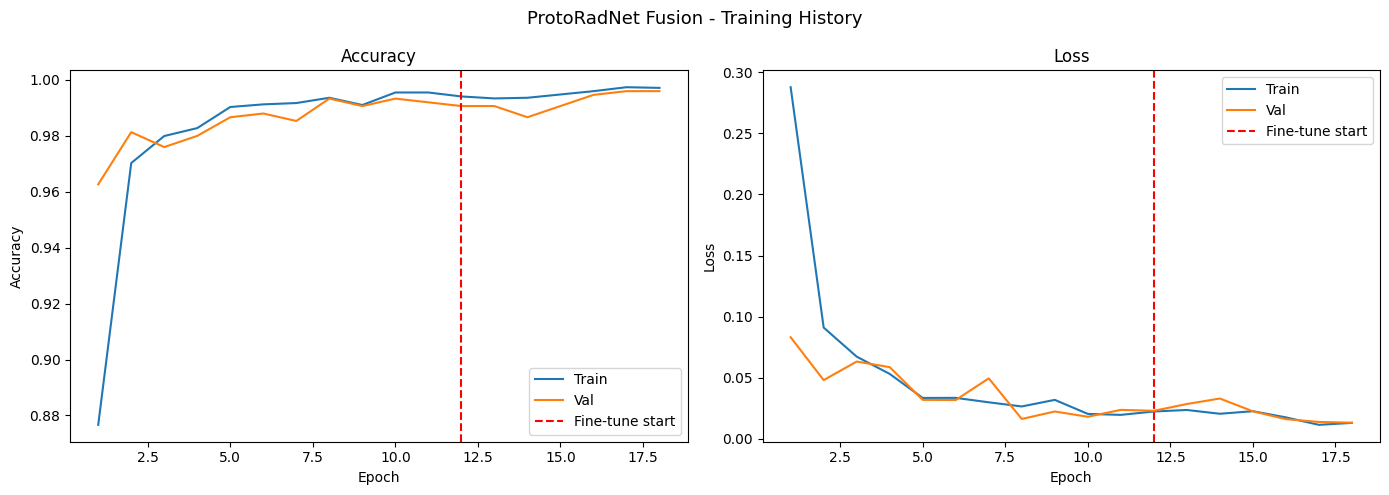

In [23]:
import json
import matplotlib.pyplot as plt

with open('training_history.json', 'r') as f:
    history_data = json.load(f)

acc = history_data.get('train_accuracy', []) + history_data.get('fine_tune_accuracy', [])
val = history_data.get('train_val_accuracy', []) + history_data.get('fine_tune_val_accuracy', [])
loss = history_data.get('train_loss', []) + history_data.get('fine_tune_loss', [])
vloss = history_data.get('train_val_loss', []) + history_data.get('fine_tune_val_loss', [])

if not acc or not val or not loss or not vloss:
    raise ValueError(
        "training_history.json does not contain the expected keys. "
        "Run the training, fine-tuning, and history-save cells first."
    )

epochs = range(1, len(acc) + 1)
ft_start = len(history_data.get('train_accuracy', []))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, acc, label='Train')
ax1.plot(epochs, val, label='Val')
if ft_start > 0:
    ax1.axvline(ft_start, color='red', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, loss, label='Train')
ax2.plot(epochs, vloss, label='Val')
if ft_start > 0:
    ax2.axvline(ft_start, color='red', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.suptitle('ProtoRadNet Fusion - Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


Confusion Matrix & Classification Report

Current Validation Accuracy: 99.60%


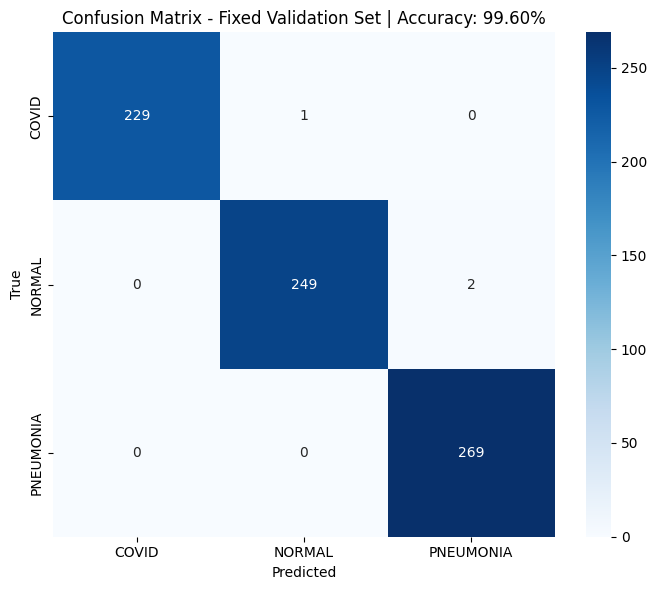


Classification Report:
              precision    recall  f1-score   support

       COVID     1.0000    0.9957    0.9978       230
      NORMAL     0.9960    0.9920    0.9940       251
   PNEUMONIA     0.9926    1.0000    0.9963       269

    accuracy                         0.9960       750
   macro avg     0.9962    0.9959    0.9960       750
weighted avg     0.9960    0.9960    0.9960       750



In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ['COVID', 'NORMAL', 'PNEUMONIA']

y_true, y_pred = [], []
for (ct_b, xr_b), lbl in val_dataset:
    preds = model.predict([ct_b, xr_b], verbose=0)
    y_true.extend(np.argmax(lbl.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
current_accuracy = accuracy_score(y_true, y_pred)

print(f"Current Validation Accuracy: {current_accuracy * 100:.2f}%")

cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title(f'Confusion Matrix - Fixed Validation Set | Accuracy: {current_accuracy * 100:.2f}%')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=range(len(CLASS_NAMES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


P-Value Hypothesis Testing

In [25]:
from scipy.stats import binomtest
import numpy as np

correct_predictions = np.sum(np.array(y_true) == np.array(y_pred))
total_predictions = len(y_true)

chance_accuracy = 1 / NUM_CLASSES

test_result = binomtest(
    k=correct_predictions,
    n=total_predictions,
    p=chance_accuracy,
    alternative='greater'
)

print("\n===== Hypothesis Testing: Model vs Random Chance =====")
print(f"Null Hypothesis H0       : Model accuracy is equal to random chance ({chance_accuracy:.2f})")
print("Alternative Hypothesis H1: Model accuracy is greater than random chance")
print(f"Correct Predictions      : {correct_predictions}/{total_predictions}")
print(f"Observed Accuracy        : {correct_predictions / total_predictions:.4f}")
print(f"P-value                  : {test_result.pvalue:.6f}")

alpha = 0.05

if test_result.pvalue < alpha:
    print("Result                   : Reject H0")
    print("Conclusion               : Model performs significantly better than random chance.")
else:
    print("Result                   : Fail to reject H0")
    print("Conclusion               : Not enough evidence that the model is better than random chance.")



===== Hypothesis Testing: Model vs Random Chance =====
Null Hypothesis H0       : Model accuracy is equal to random chance (0.33)
Alternative Hypothesis H1: Model accuracy is greater than random chance
Correct Predictions      : 747/750
Observed Accuracy        : 0.9960
P-value                  : 0.000000
Result                   : Reject H0
Conclusion               : Model performs significantly better than random chance.


## Interpretability - Highlight the Region
We extract the patch attention scores and overlay them as a heatmap on the original image, showing exactly **which spatial region** the model focused on. This maps directly to the *Highlight the Region* box in your pipeline.

       ProtoRadNet - DIAGNOSIS REPORT
  Scan Type   : CT
  Prediction  : PNEUMONIA
  Status      : Pneumonia Detected
  Confidence  : 100.0%

  All Class Probabilities:
    COVID       :   0.0%  
    NORMAL      :   0.0%  
    PNEUMONIA   : 100.0%  ############################## <


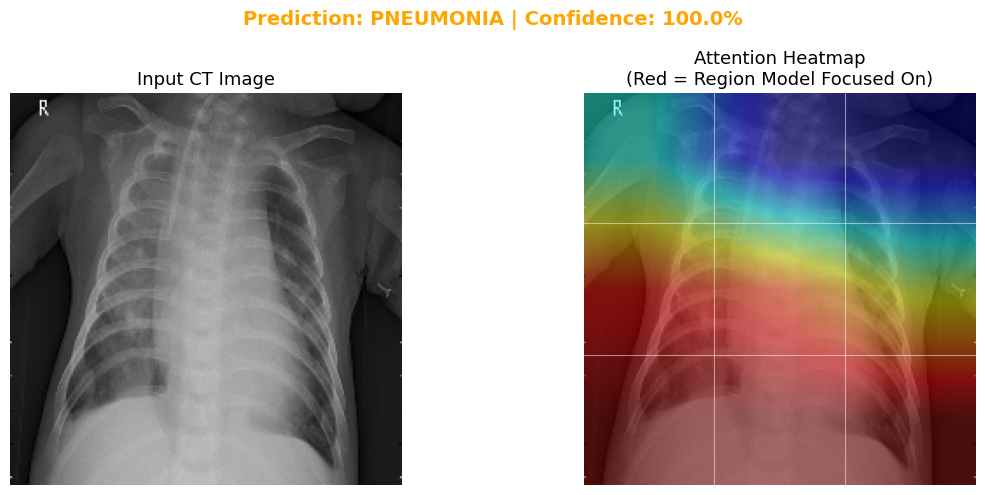

('PNEUMONIA',
 100.0,
 {'COVID': np.float32(0.0),
  'NORMAL': np.float32(0.0),
  'PNEUMONIA': np.float32(100.0)})

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

CLASS_NAMES = ['COVID', 'NORMAL', 'PNEUMONIA']
IMG_SIZE = 224

attn_model = Model(
    inputs=[ct_input, xray_input],
    outputs=model.get_layer('patch_attention').output,
    name='attention_extractor'
)


def load_image(image_path):
    image_path = str(image_path).strip().strip('"').strip("'")

    if not os.path.exists(image_path):
        raise FileNotFoundError(
            f"Image not found: {image_path}\n"
            "Check the path. Do not include extra quotes inside the raw string."
        )

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"OpenCV could not read this image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img


def overlay_attention(img, attn_grid):
    attn_grid = attn_grid.astype(np.float32)
    attn_grid = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)

    heatmap = cv2.resize(attn_grid, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return cv2.addWeighted(img, 0.55, heatmap, 0.45, 0)


def predict_scan(image_path, image_type='xray'):
    """
    Predict from a single CT or X-ray image.

    image_path : path to the image file
    image_type : 'ct' or 'xray'
    """
    image_type = image_type.lower().strip()
    if image_type not in {'ct', 'xray'}:
        raise ValueError("image_type must be either 'ct' or 'xray'")

    img = load_image(image_path)
    img_norm = (img.astype(np.float32) / 255.0)[np.newaxis, ...]

    # Your fusion model expects both CT and X-ray inputs.
    # This keeps your original behaviour: the same image is passed to both branches.
    ct_in = img_norm
    xray_in = img_norm

    probs = model.predict([ct_in, xray_in], verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx] * 100)

    attn_raw = attn_model.predict([ct_in, xray_in], verbose=0)[0, :, 0]
    if image_type == 'ct':
        attn_grid = attn_raw[:9].reshape(3, 3)
    else:
        attn_grid = attn_raw[9:18].reshape(3, 3)

    if pred_label == 'NORMAL':
        status = 'No Disease Detected'
        color = 'green'
    elif pred_label == 'COVID':
        status = 'COVID-19 Detected'
        color = 'red'
    else:
        status = 'Pneumonia Detected'
        color = 'orange'

    print("=" * 50)
    print("       ProtoRadNet - DIAGNOSIS REPORT")
    print("=" * 50)
    print(f"  Scan Type   : {image_type.upper()}")
    print(f"  Prediction  : {pred_label}")
    print(f"  Status      : {status}")
    print(f"  Confidence  : {confidence:.1f}%")
    if confidence < 60:
        print("  Low confidence - consider using both CT and XRay")
    print()
    print("  All Class Probabilities:")
    for i, name in enumerate(CLASS_NAMES):
        bar = '#' * int(probs[i] * 30)
        marker = ' <' if i == pred_idx else ''
        print(f"    {name:<12}: {probs[i] * 100:5.1f}%  {bar}{marker}")
    print("=" * 50)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.imshow(img)
    ax1.set_title(f'Input {image_type.upper()} Image', fontsize=13)
    ax1.axis('off')

    ax2.imshow(overlay_attention(img, attn_grid))
    ax2.set_title('Attention Heatmap\n(Red = Region Model Focused On)', fontsize=13)
    ax2.axis('off')

    for k in range(1, 3):
        ax2.axhline(y=k * IMG_SIZE // 3, color='white', linewidth=0.8, alpha=0.5)
        ax2.axvline(x=k * IMG_SIZE // 3, color='white', linewidth=0.8, alpha=0.5)

    plt.suptitle(
        f'Prediction: {pred_label} | Confidence: {confidence:.1f}%',
        fontsize=14,
        color=color,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('diagnosis_result.png', dpi=150)
    plt.show()

    return pred_label, confidence, dict(zip(CLASS_NAMES, (probs * 100).round(2)))


# Example path from this project. Change this to your test image path.
predict_scan(
    image_path=r'Sample_lg.jpeg',
    image_type='ct'
)
